In [1]:
# read in the dataset

import pandas as pd
import numpy as np

df = pd.read_parquet("../datasets/modelling_dataset.parquet")
df.head(20)

,Time_Stamp,Year,Hour,Day_of_Week,Month,Weekend,Holiday,Zone_Int_ID,Amenity,Crossing,...,Wind_Speed(mph),Precipitation(in),Weather_Clear,Weather_Cloudy,Weather_Dust/Windy,Weather_Rain/Drizzle,Weather_Snow/Ice,Weather_Stormy,Weather_Visibility Issues,Accident_Count
0,2016-06-14 20:00:00,2016,20,1,6,0,0,0,0.041169,0.233068,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,2016-06-14 20:00:00,2016,20,1,6,0,0,1,0.030181,0.424547,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2016-06-14 20:00:00,2016,20,1,6,0,0,2,0.000000,0.316667,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2016-06-14 20:00:00,2016,20,1,6,0,0,3,0.000000,0.161290,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2016-06-14 20:00:00,2016,20,1,6,0,0,4,0.000000,0.021277,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,2016-06-14 20:00:00,2016,20,1,6,0,0,5,0.016787,0.326139,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,2016-06-14 20:00:00,2016,20,1,6,0,0,6,0.012476,0.208253,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7,2016-06-14 20:00:00,2016,20,1,6,0,0,7,0.007648,0.072658,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
8,2016-06-14 20:00:00,2016,20,1,6,0,0,8,0.000000,0.134396,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9,2016-06-14 20:00:00,2016,20,1,6,0,0,9,0.010929,0.072860,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4701290 entries, 0 to 4701289
Data columns (total 33 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   Time_Stamp                 datetime64[ns]
 1   Year                       int32         
 2   Hour                       int32         
 3   Day_of_Week                int32         
 4   Month                      int32         
 5   Weekend                    int64         
 6   Holiday                    int64         
 7   Zone_Int_ID                int64         
 8   Amenity                    float64       
 9   Crossing                   float64       
 10  Give_Way                   float64       
 11  Junction                   float64       
 12  Railway                    float64       
 13  Station                    float64       
 14  Stop                       float64       
 15  Traffic_Signal             float64       
 16  City_Houston               bool     

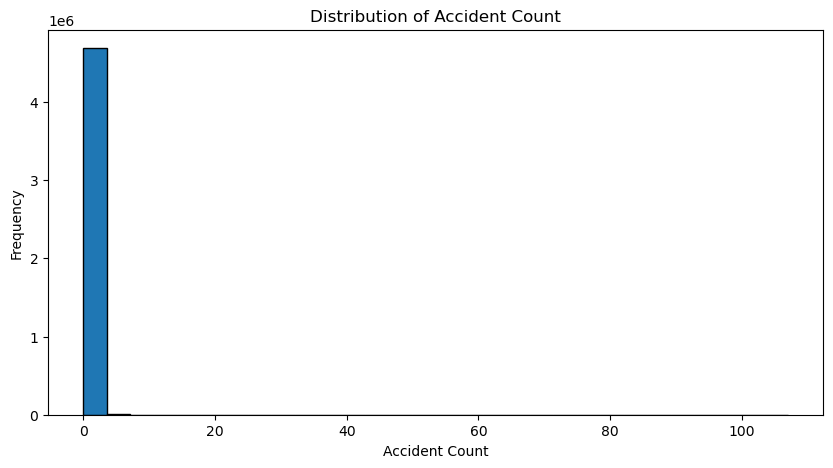

In [3]:
import matplotlib.pyplot as plt

# show the distribution of the target variable
# after performing data cleaning, we can see that we have heavy zero inflation
plt.figure(figsize=(10, 5))
plt.hist(df['Accident_Count'], bins=30, edgecolor='black')
plt.xlabel('Accident Count')
plt.ylabel('Frequency')
plt.title('Distribution of Accident Count')
plt.show()

In [4]:
# from this we see that the variance is ~5.3x the mean (Poisson needs mean=variance) meaning we have overdispersion
print(f"Mean: {round(df['Accident_Count'].mean(), 4)}")
print(f"Variance: {round(df['Accident_Count'].var(), 4)}")
print(f"% zeros: {round((df['Accident_Count'] == 0).mean() * 100, 4)}%")

Mean: 0.0752
Variance: 0.4009
% zeros: 95.6542%


In [5]:
import numpy as np

# can't use train_test_split because it randomly shuffles and we need to maintain order due to time-series
d2 = df.sort_values('Time_Stamp')

n = len(df)

# split into 70% train, 15% val, 15% test
train_df = d2.iloc[:int(n*0.7)]
val_df = d2.iloc[int(n*0.7):int(n*0.85)]
test_df = d2.iloc[int(n*0.85):]


In [6]:
drop_cols = ['Time_Stamp', 'Accident_Count']

# establish X and y for each set, dropping the timestamp and target variable from X
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['Accident_Count']

# do the same for val and test sets
X_val = val_df.drop(columns=drop_cols)
y_val = val_df['Accident_Count']

# and for test set
X_test = test_df.drop(columns=drop_cols)
y_test = test_df['Accident_Count']

In [7]:
# Poisson predicts a single narrow range for all inputs (if std is far lower than actual std)
# the model has learned no meaningful signal and cannot distinguish high-risk from low-risk zones

from sklearn.linear_model import PoissonRegressor

# encode high-cardinality categorical columns (zone_id) using train-only frequency encoding.
# this keeps the signal while ensuring all model inputs are numeric.
obj_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

X_train_enc = X_train.copy()
X_val_enc = X_val.copy()

for col in obj_cols:
    freq_map = X_train[col].value_counts(normalize=True)
    X_train_enc[f"{col}_freq"] = X_train[col].map(freq_map).fillna(0.0)
    X_val_enc[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0.0)

# drop raw string columns after encoding
X_train_enc = X_train_enc.drop(columns=obj_cols)
X_val_enc = X_val_enc.drop(columns=obj_cols)

# convert boolean columns to integers for explicit numeric input
for data in (X_train_enc, X_val_enc):
    bool_cols = data.select_dtypes(include=['bool']).columns
    data[bool_cols] = data[bool_cols].astype(int)

poisson_model = PoissonRegressor(max_iter=300)
poisson_model.fit(X_train_enc, y_train)

poisson_predictions = poisson_model.predict(X_val_enc)

# lowest and highest risk score the model ever assigns, it should span 0 to 100+ if it were meaningful
print(f"Predicted min: {round(poisson_predictions.min(), 2)}")
print(f"Predicted max: {round(poisson_predictions.max(), 2)}")

# how much the predictions vary across all zones/hours, near zero means the model predicts the same thing everywhere
print(f"Predicted std: {round(poisson_predictions.std(), 2)}")

# how much the actual counts vary, the gap between this and predicted std reveals how blind the model is
print(f"Actual std: {round(y_val.std(), 2)}")

Predicted min: 0.01
Predicted max: 0.21
Predicted std: 0.04
Actual std: 1.09


# Results
## The predicted std is 27.25x smaller than actual std, which means the model assigns nearly identical scores to every row regardless of features, meaning it cannot identify high-risk zones at all. Since the goal is to identify WHICH zones are dangerous (not predict exact counts), we need to reframe this as a classification problem: did an accident occur?